In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

# 1.

9.494949494949495


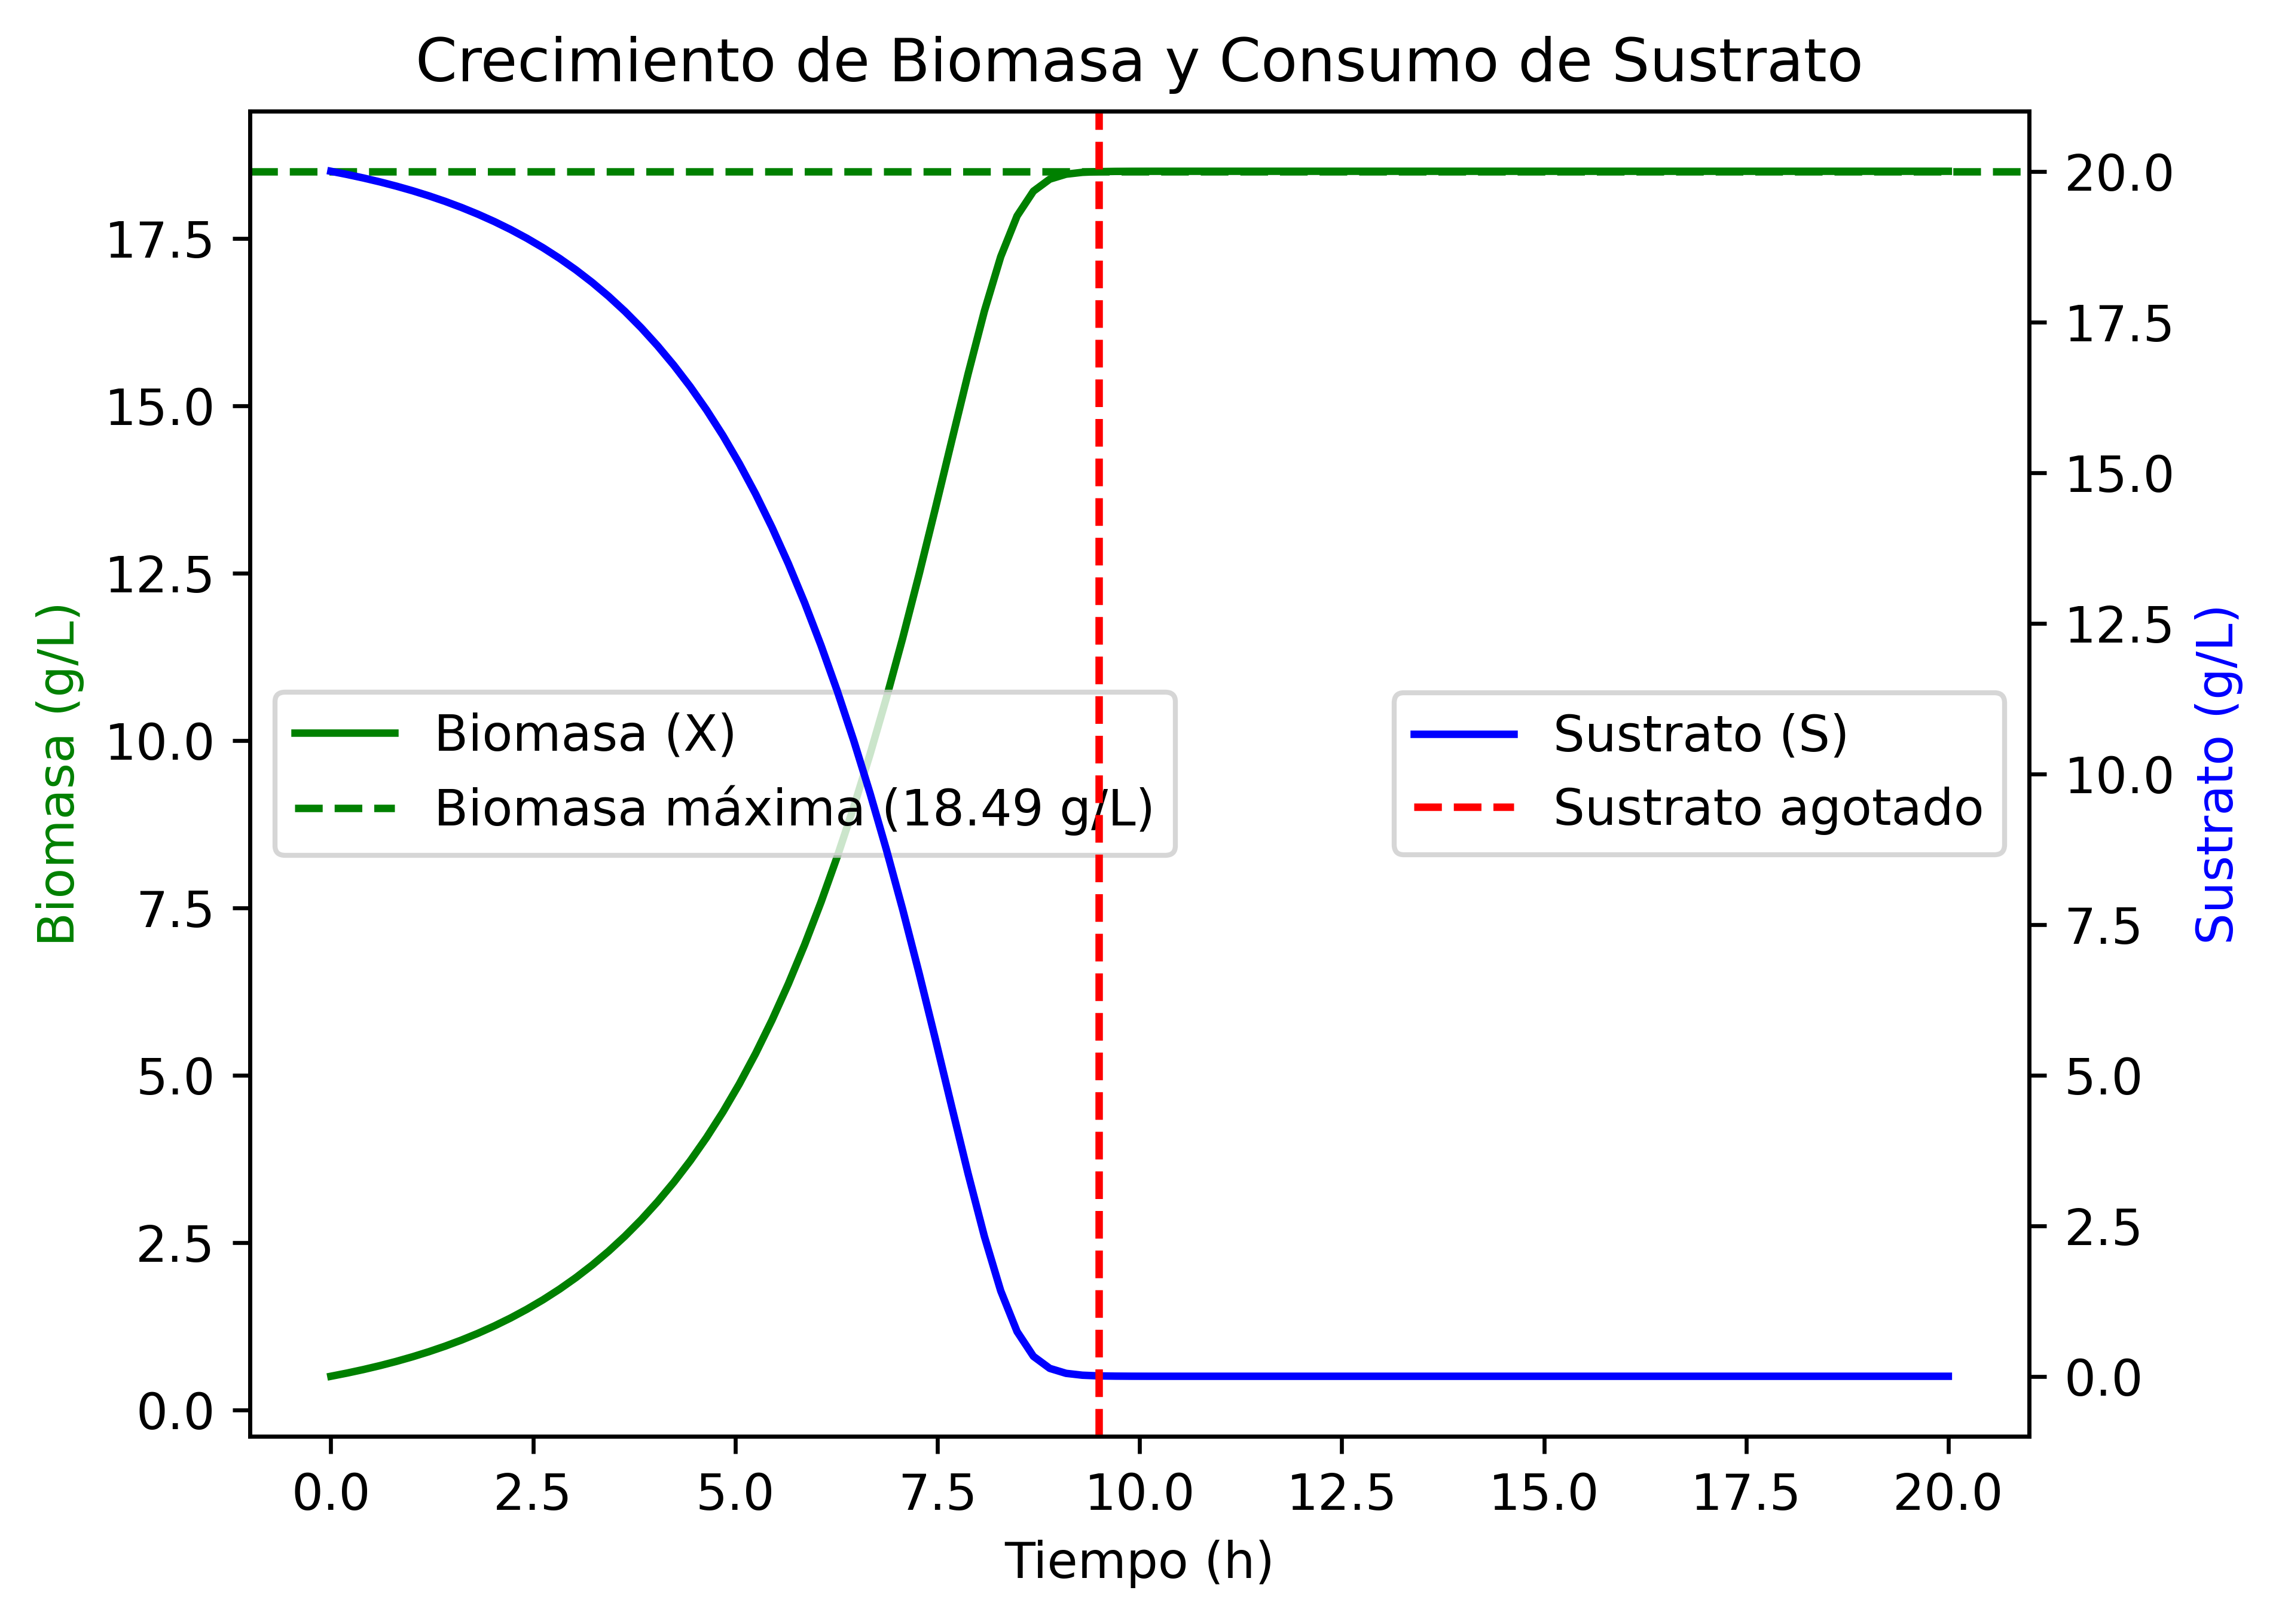

In [27]:
def ode_bio(t, x, params):
    X, S = x
    mu_max, K_s, Y_xs = params
    mu = mu_max * S / (K_s + S)
    dx_dt = mu * X
    ds_dt = - mu * 1/Y_xs * X
    return [dx_dt, ds_dt]

t_eval = np.linspace(0, 20, 100)
x0 = [0.5, 20]
params = [0.5, 2, 0.9]
solution = scipy.integrate.solve_ivp(ode_bio, [t_eval[0], t_eval[-1]], x0, args=(params,), t_eval=t_eval)
X = solution.y[0]
S = solution.y[1]
S_0 = np.isclose(S, 0, atol=1e-2)
# first S-0
S_0_index = np.where(S_0)[0][0]
print(t_eval[S_0_index] )

X_max = X[S_0_index]


fig, ax1 = plt.subplots(dpi = 600)
ax2 = ax1.twinx()
ax1.plot(t_eval, X, 'g-', label='Biomasa (X)')
ax2.plot(t_eval, S, 'b-', label='Sustrato (S)')
ax1.axhline(y=X_max, color='g', linestyle='--', label=f'Biomasa máxima ({X_max:.2f} g/L)')
ax2.axvline(x=t_eval[S_0_index], color='r', linestyle='--', label='Sustrato agotado')

ax1.set_xlabel('Tiempo (h)')
ax1.set_ylabel('Biomasa (g/L)', color='g')
ax2.set_ylabel('Sustrato (g/L)', color='b')
ax1.legend(loc = 'center left')
ax2.legend(loc = 'center right')
plt.title('Crecimiento de Biomasa y Consumo de Sustrato')
plt.show()

# 2.

Text(0, 0.5, 'Concentración de CO2 (g/L)')

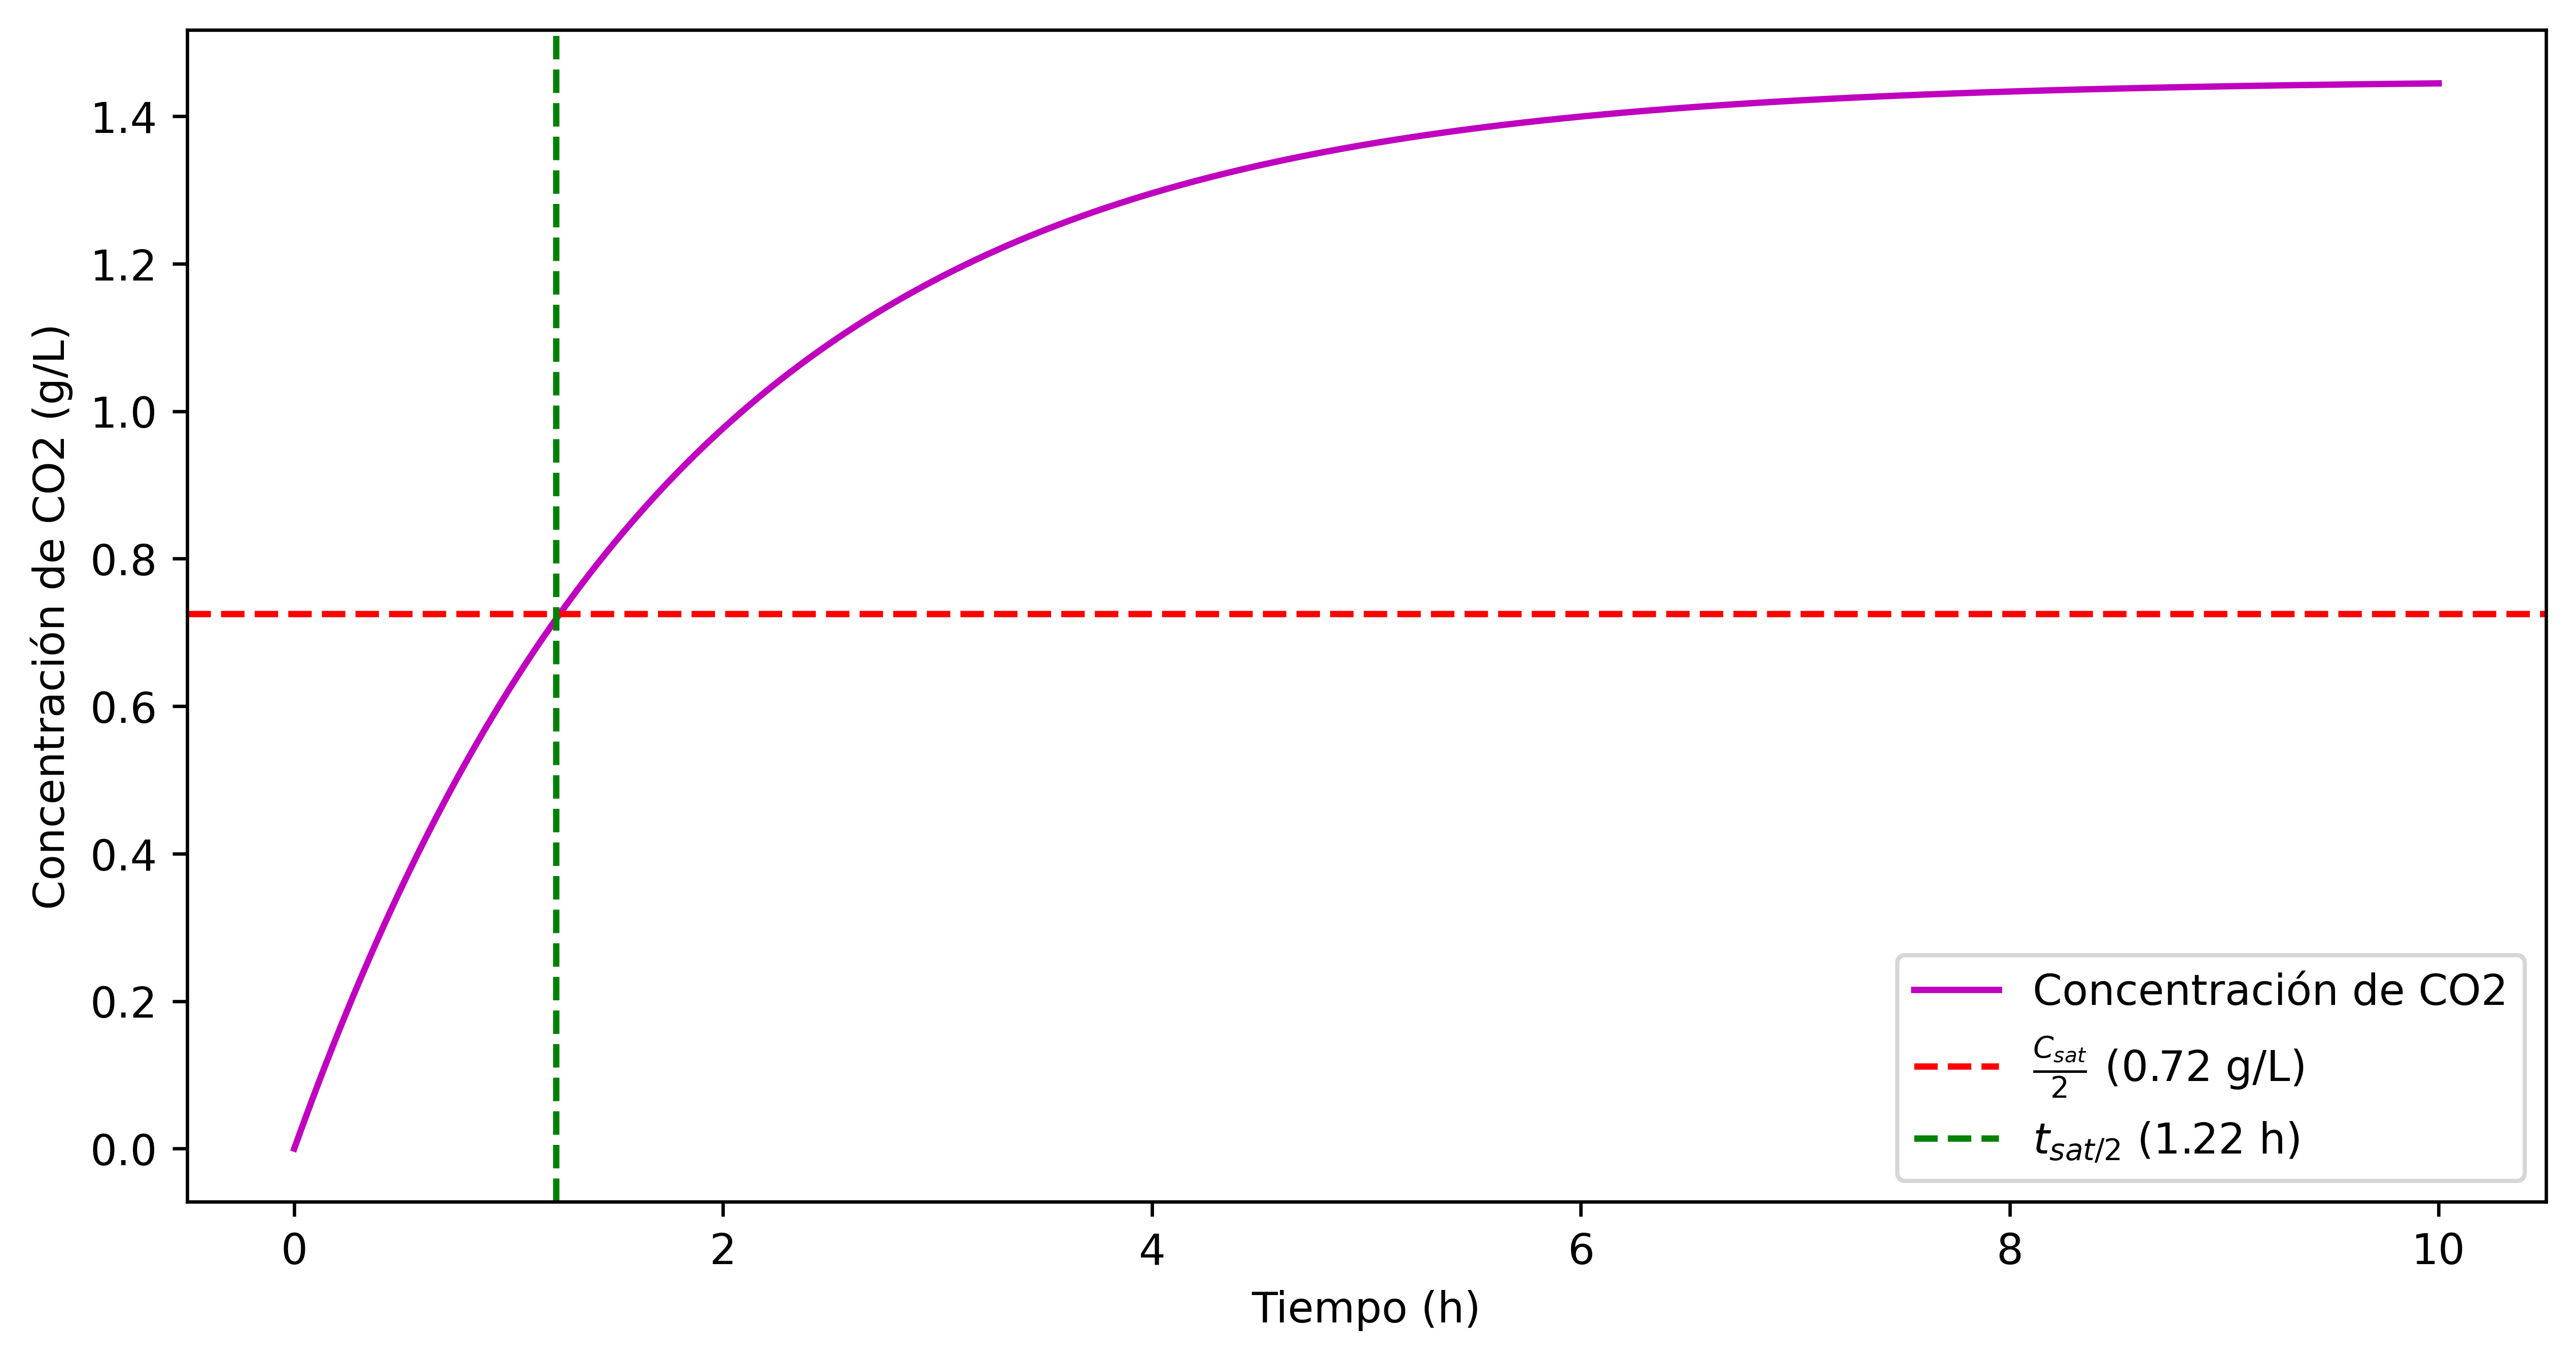

In [43]:
def C_co2(C_sat, Kl, a, t):
    return C_sat * (1 - np.exp(-Kl * a * t))
C_sat = 1.45
Kl = 0.8
a = 0.7
t = np.linspace(0, 10, 1000)
C_co2_values = C_co2(C_sat, Kl, a, t)
t_at = t[np.isclose(C_co2_values, C_sat/2, atol=1e-2)][0]
fig, ax = plt.subplots(dpi = 600, figsize=(10, 5))
ax.plot(t, C_co2_values, 'm-', label='Concentración de CO2')
ax.axhline(y=C_sat/2, color='r', linestyle='--', label=r'$\frac{C_{sat}}{2}$' + f' ({C_sat/2:.2f} g/L)')
ax.axvline(x=t_at, color='g', linestyle='--', label=r'$t_{sat/2}$' + f' ({t_at:.2f} h)')
ax.legend()
ax.set_xlabel('Tiempo (h)')
ax.set_ylabel('Concentración de CO2 (g/L)')

# 3.

In [47]:
import pandas as pd
dataset = pd.read_excel('ay11_ds.xls')
dataset.rename(columns={'T(seg)': 'T'}, inplace=True)

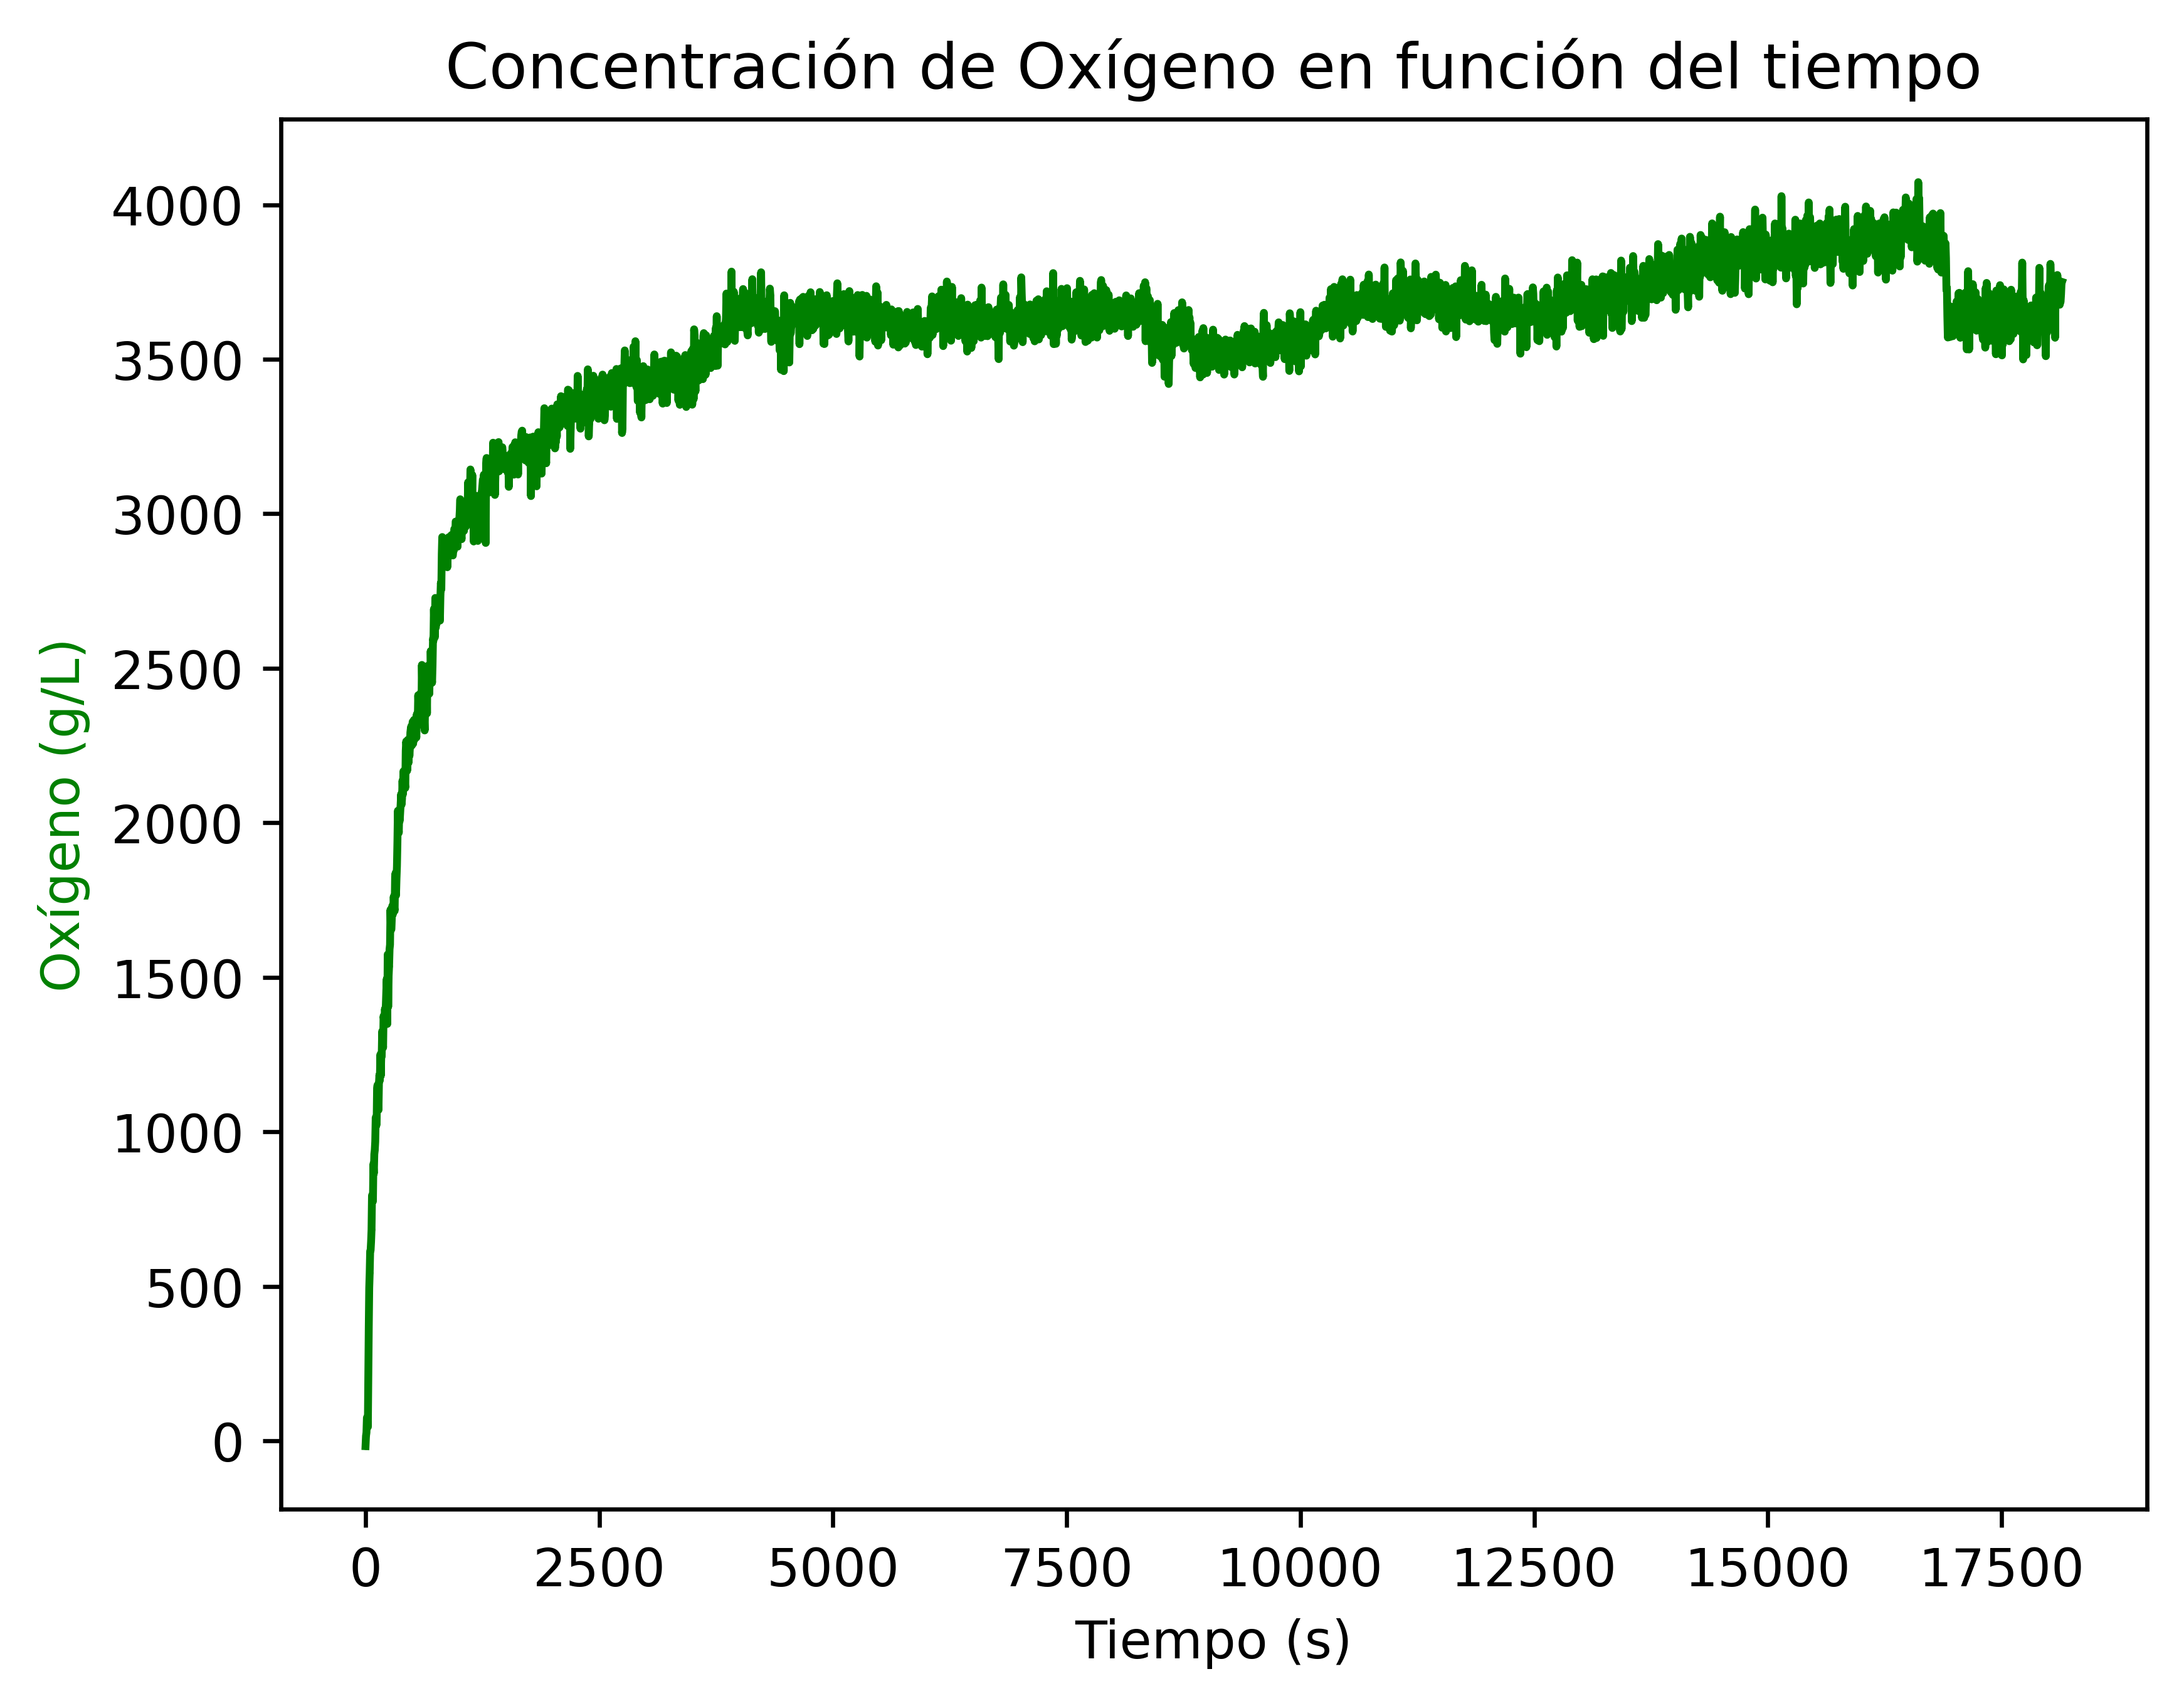

In [ ]:
fig, ax = plt.subplots(dpi = 600)
ax.plot(dataset['T'], dataset['Oxi'], 'o-',
        color='g', markersize=0.2)
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Oxígeno (g/L)', color='g')
ax.legend()
plt.title('Concentración de Oxígeno en función del tiempo')
plt.show()


Text(0, 0.5, 'Oxígeno (g/L)')

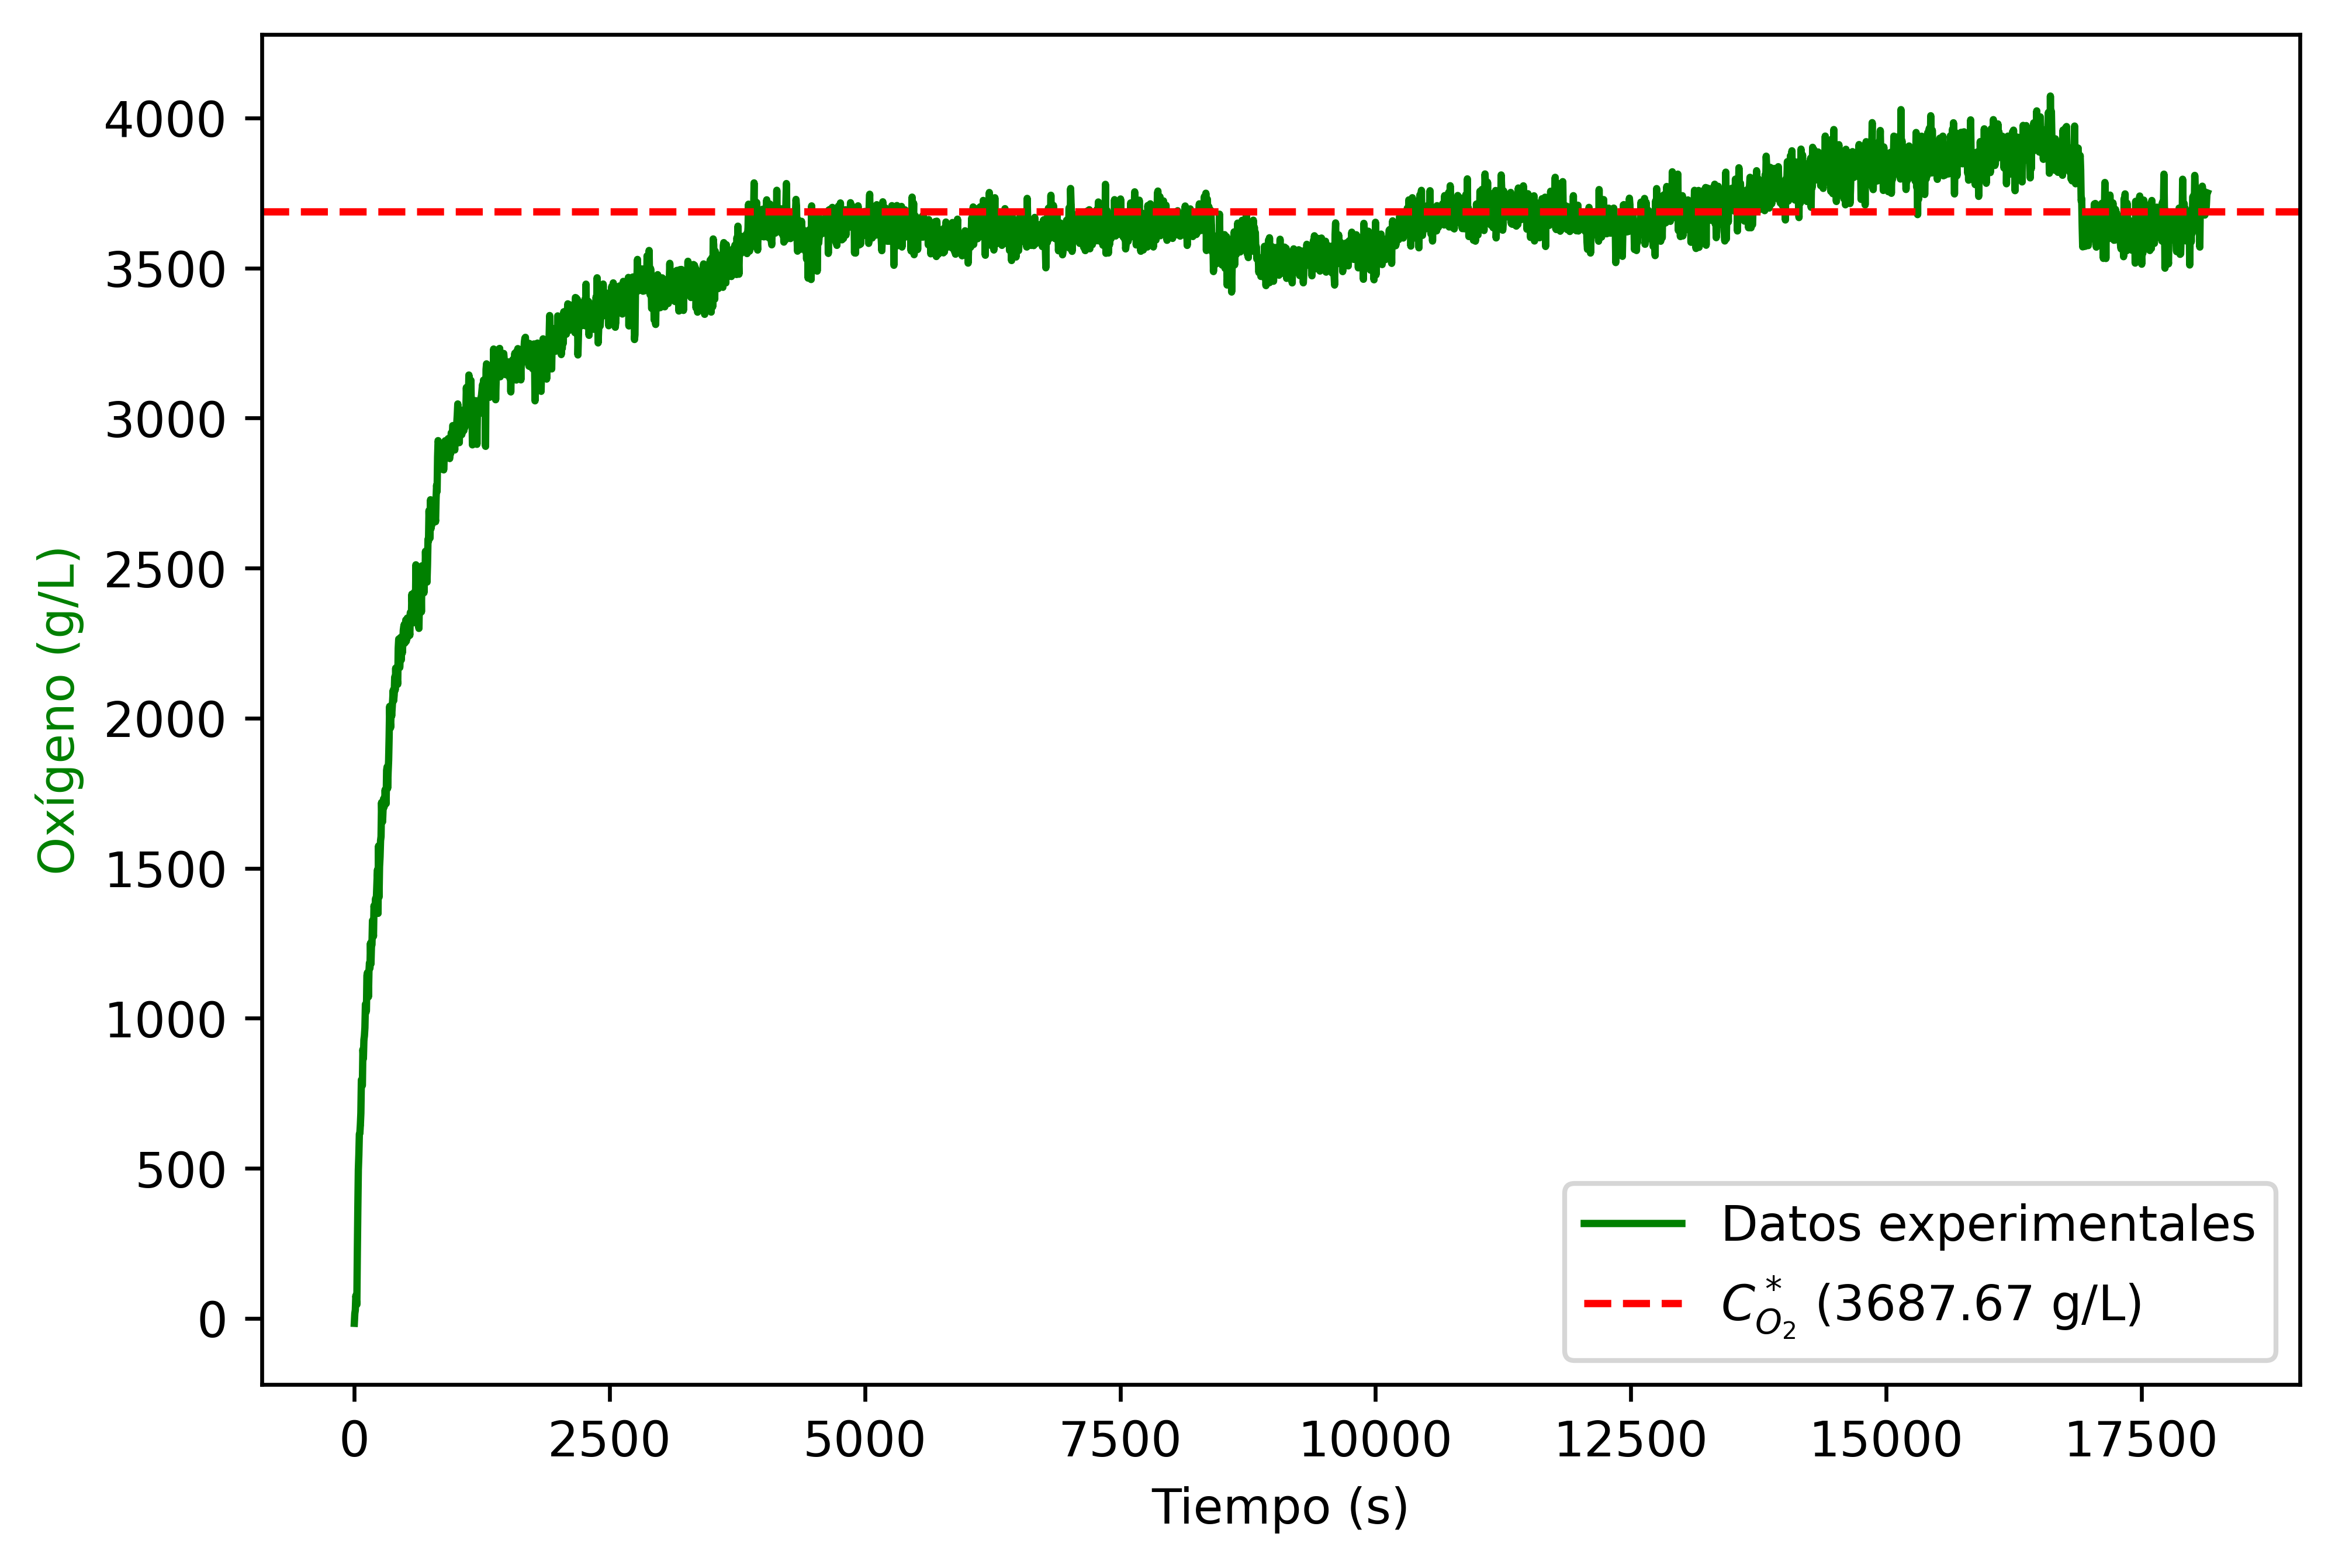

In [67]:
# saturacion como media a partir de tiempo 5000
saturacion = dataset[dataset['T'] >= 5000]['Oxi'].mean()
fig, ax = plt.subplots(dpi = 600, figsize=(7.5, 5))
ax.plot(dataset['T'], dataset['Oxi'], 'o-',
        color='g', markersize=0.2, label='Datos experimentales')
ax.axhline(y=saturacion, color='r', linestyle='--', label=r'$C^*_{O_2}$' + f' ({saturacion:.2f} g/L)')
ax.set_xlabel('Tiempo (s)')
ax.legend()
ax.set_ylabel('Oxígeno (g/L)', color='g')

Valor óptimo de KLa: 0.0016 1/h


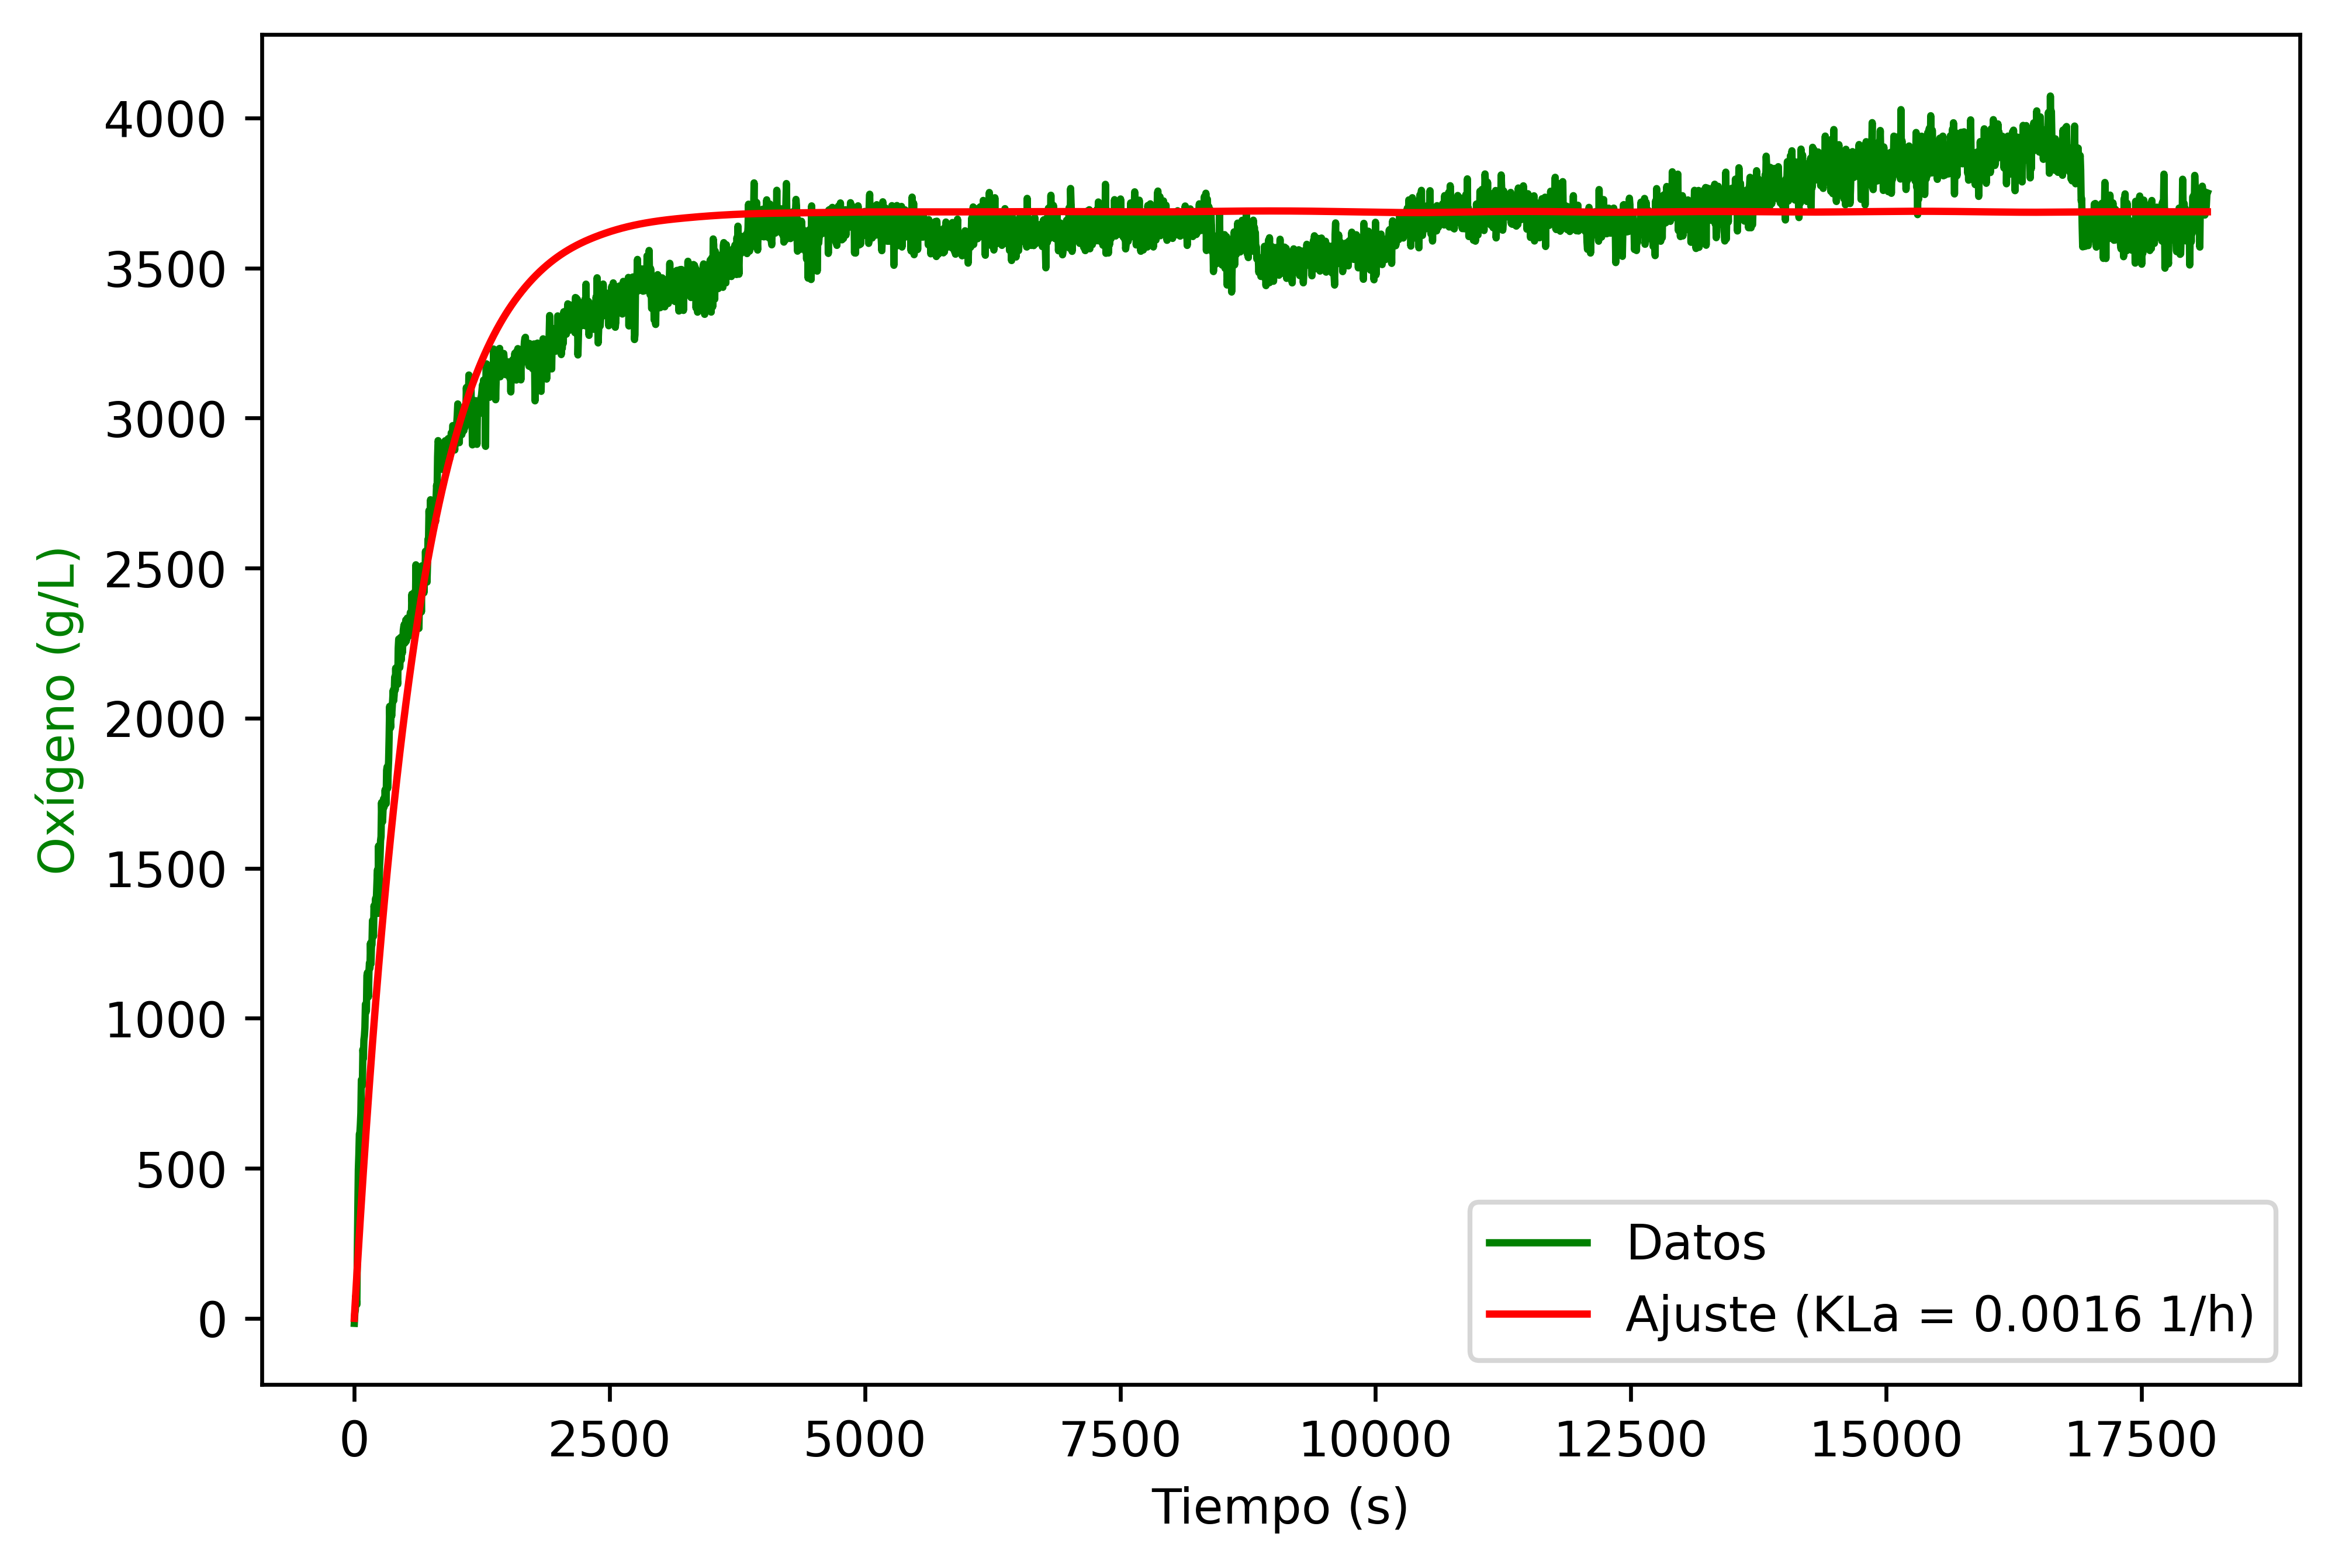

In [70]:

from scipy.optimize import minimize_scalar
def co2_ode(t, C, kla):
    return kla * (saturacion - C)

def objective(kla):
    solution = scipy.integrate.solve_ivp(co2_ode, [dataset['T'].min(), dataset['T'].max()], [0], args=(kla,), t_eval=dataset['T'])
    C_simulated = solution.y[0]
    return np.sum((C_simulated - dataset['Oxi'])**2)/len(dataset) * 1/C_simulated.max()  # normalizar por la concentración máxima simulada

result = minimize_scalar(objective, bounds=(1e-12, 1), method='bounded')
kla_optimal = result.x
print(f'Valor óptimo de KLa: {kla_optimal:.4f} 1/h')

# ajuste

solution = scipy.integrate.solve_ivp(co2_ode, [dataset['T'].min(), dataset['T'].max()], [0], args=(kla_optimal,), t_eval=dataset['T'])
C_simulated = solution.y[0]
fig, ax = plt.subplots(dpi = 600, figsize=(7.5, 5))
ax.plot(dataset['T'], dataset['Oxi'], 'o-', color='g', markersize=0.2, label='Datos')
ax.plot(dataset['T'], C_simulated, 'r-', label=f'Ajuste (KLa = {kla_optimal:.4f} 1/h)')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Oxígeno (g/L)', color='g')
ax.legend()

Valor óptimo de KLa: 0.0017 1/h


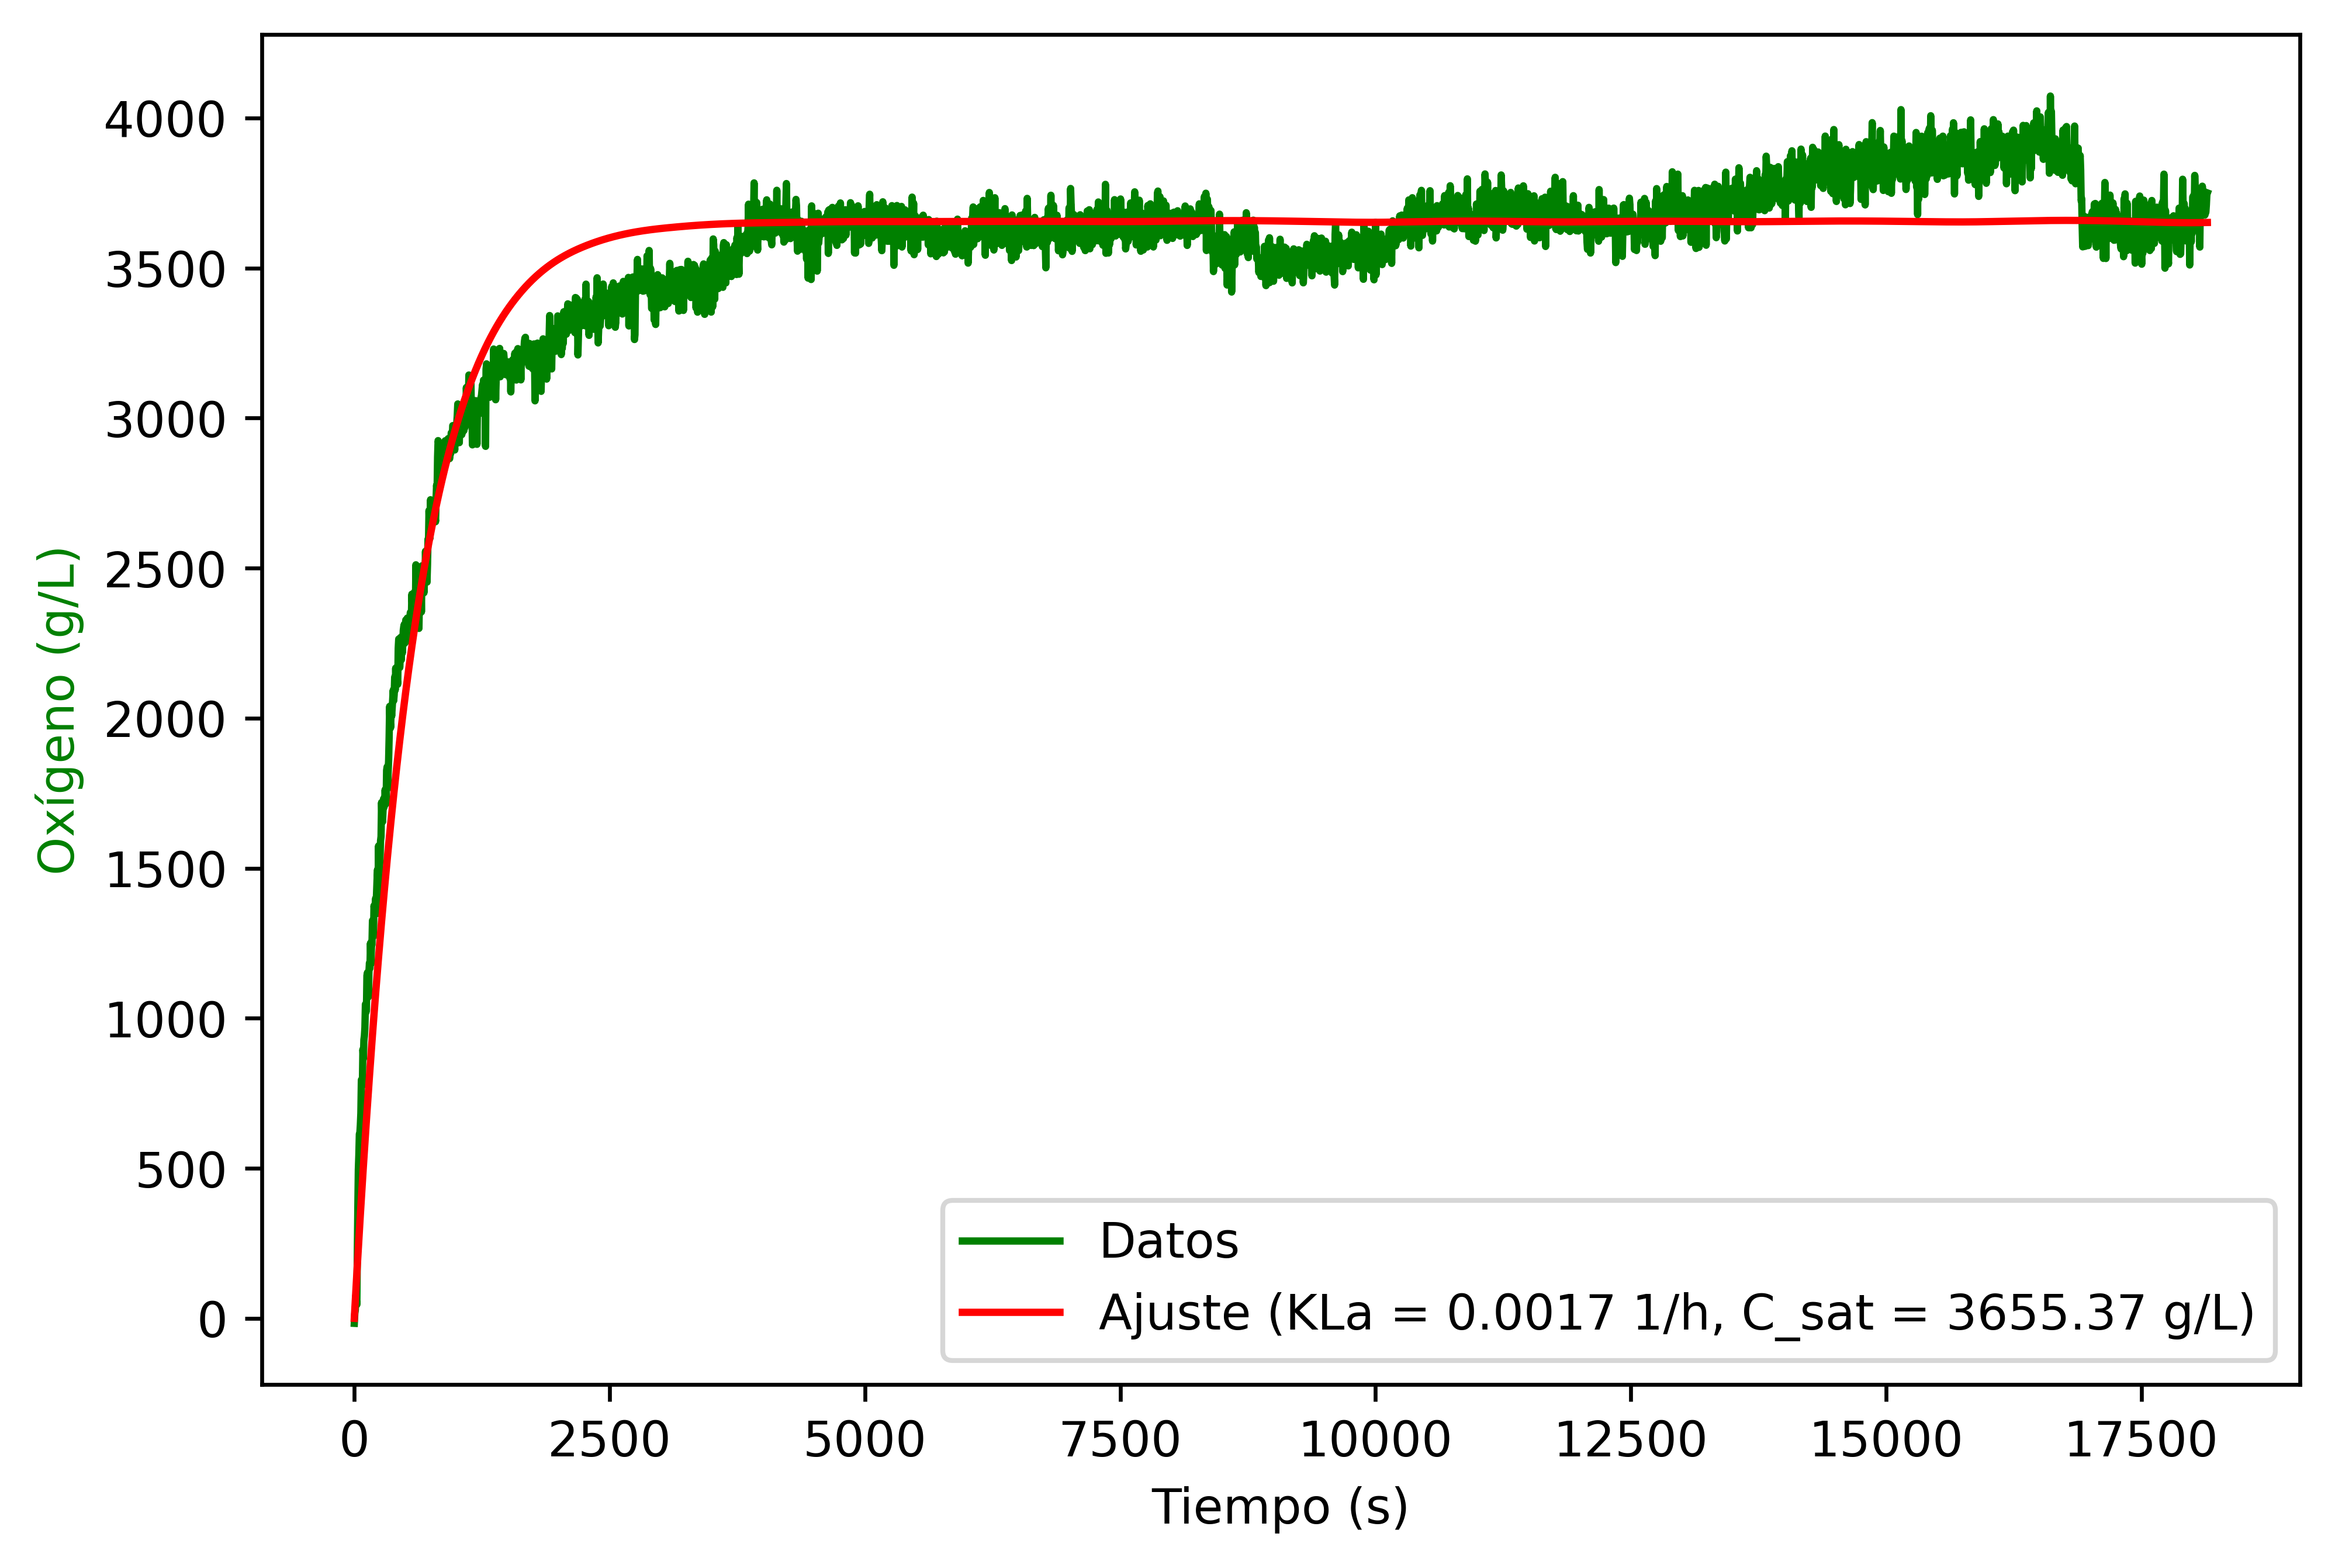

In [77]:

from scipy.optimize import minimize
def co2_ode(t, C, params):
    sat, kla = params
    return kla * (sat - C)

def objective(params):

    solution = scipy.integrate.solve_ivp(co2_ode, [dataset['T'].min(), dataset['T'].max()], [0], args=(params,), t_eval=dataset['T'])
    C_simulated = solution.y[0]
    return np.sum((C_simulated - dataset['Oxi'])**2)/len(dataset) * 1/C_simulated.max()  # normalizar por la concentración máxima simulada

result = minimize(objective, x0=[saturacion, 1e-12], bounds=[(3000, 4000), (1e-12, 1)], method='L-BFGS-B')
sat_optimal, kla_optimal = result.x
print(f'Valor óptimo de KLa: {kla_optimal:.4f} 1/h')

# ajuste

solution = scipy.integrate.solve_ivp(co2_ode, [dataset['T'].min(), dataset['T'].max()], [0], args=([sat_optimal, kla_optimal],), t_eval=dataset['T'])
C_simulated = solution.y[0]
fig, ax = plt.subplots(dpi = 600, figsize=(7.5, 5))
ax.plot(dataset['T'], dataset['Oxi'], 'o-', color='g', markersize=0.2, label='Datos')
ax.plot(dataset['T'], C_simulated, 'r-', label=f'Ajuste (KLa = {kla_optimal:.4f} 1/h, C_sat = {sat_optimal:.2f} g/L)')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Oxígeno (g/L)', color='g')
ax.legend()